In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)


Saving Truck_sales.csv to Truck_sales.csv


In [3]:
df

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223
...,...,...
139,14-Aug,933
140,14-Sep,704
141,14-Oct,639
142,14-Nov,571


In [4]:
df.columns

Index(['Month-Year', 'Number_Trucks_Sold'], dtype='object')

In [5]:
n_rows = len(df)
dates = pd.date_range(start='2003-01-01', end='2014-12-01', freq='MS')
dates = dates[:n_rows]
df['Date'] = dates

In [6]:
df

,Month-Year,Number_Trucks_Sold,Date
0,03-Jan,155,2003-01-01
1,03-Feb,173,2003-02-01
2,03-Mar,204,2003-03-01
3,03-Apr,219,2003-04-01
4,03-May,223,2003-05-01
...,...,...,...
139,14-Aug,933,2014-08-01
140,14-Sep,704,2014-09-01
141,14-Oct,639,2014-10-01
142,14-Nov,571,2014-11-01


Text(0, 0.5, 'Truck Sales')

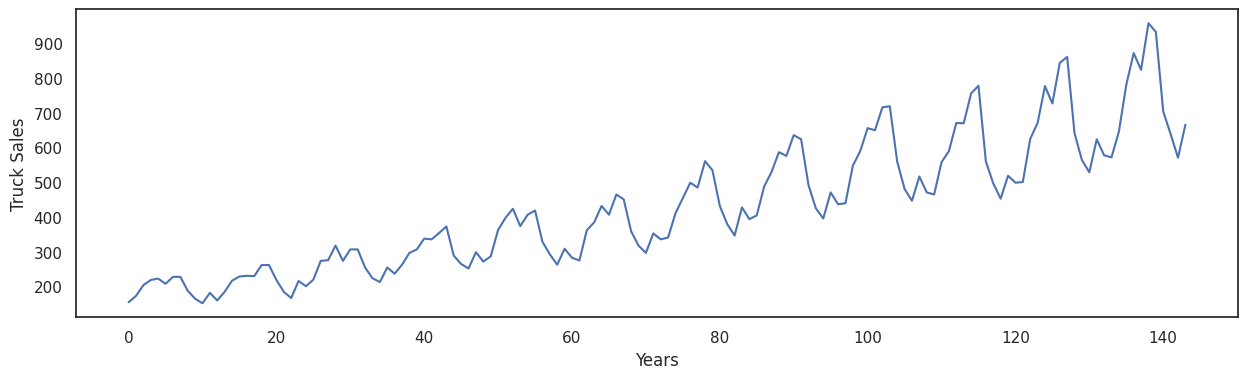

In [7]:
sales_ts = df['Number_Trucks_Sold']
sns.set(style="white", rc={'figure.figsize': (15, 4)})
plt.figure(figsize=(15, 4))
plt.plot(sales_ts)
plt.xlabel('Years')
plt.ylabel('Truck Sales')

In [9]:
sequence_length = 12
values = df['Number_Trucks_Sold'].values

X = []
y = []

for i in range(len(values) - sequence_length):
    X.append(values[i:i + sequence_length])
    y.append(values[i + sequence_length])

X = np.array(X)
y = np.array(y)

train_idx = int(len(X) * 0.8)

X_train = X[:train_idx]
y_train = y[:train_idx]

X_test = X[train_idx:]
y_test = y[train_idx:]

X_train = X_train.reshape(-1, sequence_length, 1)
X_test = X_test.reshape(-1, sequence_length, 1)

In [10]:
len(X_train)

105

In [11]:
len(X_test)

27

In [12]:
X_train.shape

(105, 12, 1)

In [13]:
y_train.shape

(105,)

In [14]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [17]:
import tensorflow as tf
import keras
from keras import layers
from keras.layers import Dense, SimpleRNN

In [19]:
from tensorflow.keras import Input, Model
inputs = Input(shape=(12, 1))
x = SimpleRNN(50, activation='relu', return_sequences=False)(inputs)
outputs = Dense(1)(x)
model = Model(inputs=inputs, outputs=outputs)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.fit(X_train, y_train, epochs=15)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 122294.4766 - mae: 327.2688
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 95310.4453 - mae: 287.3156 
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 70918.1172 - mae: 247.1810
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 51503.3477 - mae: 208.1347
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 30989.4746 - mae: 155.0663 
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 10076.9893 - mae: 81.7823
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7412.3740 - mae: 64.7209
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9378.1797 - mae: 71.6444 
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4597.8828 - mae: 53.9457
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4777.9521 - mae: 57.9749
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5378.8281 - mae: 61.3084
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4513.0854 - mae: 57.022

In [20]:
cell = keras.layers.SimpleRNNCell(50, activation='relu')
rnn_layer = keras.layers.RNN(cell, return_sequences=False)

inputs = keras.Input(shape=(12, 1))
x = rnn_layer(inputs)
outputs = keras.layers.Dense(1)(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.fit(X_train, y_train, epochs=15)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 127484.6953 - mae: 332.5981
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 83259.0469 - mae: 265.2359 
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 46990.1602 - mae: 192.0173
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16652.5117 - mae: 100.3014
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10494.1680 - mae: 84.1039
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 14138.5811 - mae: 87.3902 
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6743.1348 - mae: 65.1799
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5220.4663 - mae: 60.9176
Epoch 9/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5810.1846 - mae: 60.5020
Epoch 10/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4497.1772 - mae: 55.2700
Epoch 11/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3480.3494 - mae: 50.8126
Epoch 12/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3759.7891 - mae: 49.7295


In [22]:
y_pred = model.predict(X_test)

print("Предсказания:", y_pred[:10].flatten())
print("Реальные значения:", y_test[:10].flatten())

y_train_pred = model.predict(X_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Предсказания: [594.90784 508.67615 507.57324 511.75574 538.0548  576.32214 623.2451
 689.797   705.223   723.2016 ]
Реальные значения: [497 453 519 499 501 625 671 777 727 844]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


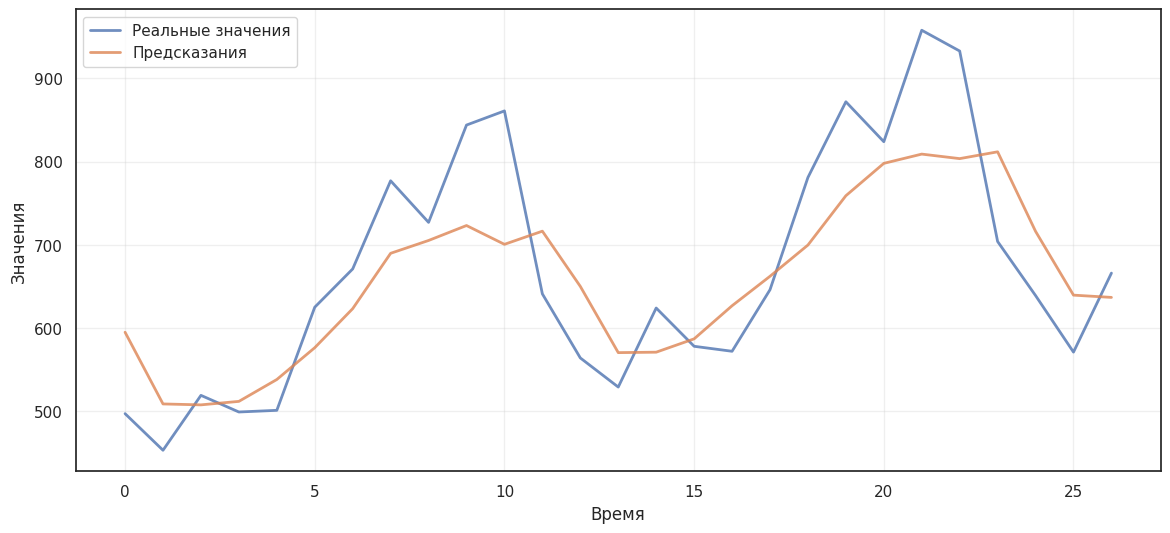

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(y_test[:100], label='Реальные значения', linewidth=2, alpha=0.8)
plt.plot(y_pred[:100], label='Предсказания', linewidth=2, alpha=0.8)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Значения', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


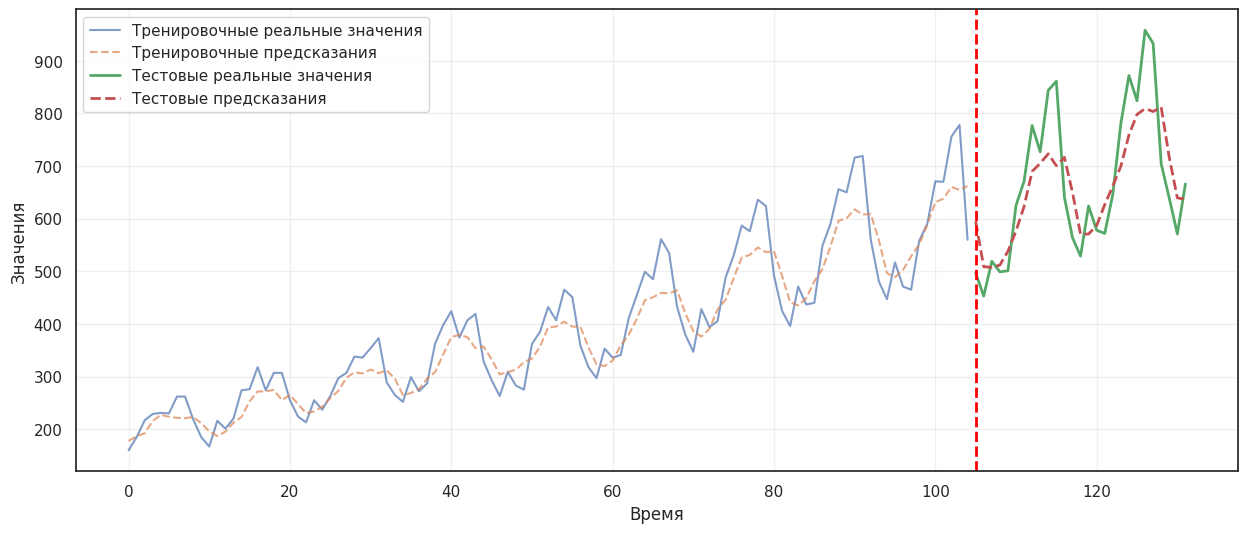

In [28]:
plt.figure(figsize=(15, 6))

train_len = len(X_train)
test_len = len(X_test)

y_train_pred = model.predict(X_train)

plt.plot(range(train_len), y_train[:train_len], label='Тренировочные реальные значения', linewidth=1.5, alpha=0.7)
plt.plot(range(train_len), y_train_pred, label='Тренировочные предсказания', linewidth=1.5, alpha=0.7, linestyle='--')
plt.plot(range(train_len, train_len + test_len), y_test, label='Тестовые реальные значения', linewidth=2)
plt.plot(range(train_len, train_len + test_len), y_pred, label='Тестовые предсказания', linewidth=2, linestyle='--')

plt.axvline(x=train_len, color='red', linestyle='--', linewidth=2)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Значения', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
from keras.layers import Dense, GRU

rnn_layer = GRU(50, activation='relu', return_sequences=False)

inputs = keras.Input(shape=(12, 1))
x = rnn_layer(inputs)
outputs = Dense(1)(x)

model_GRU = keras.Model(inputs=inputs, outputs=outputs)

model_GRU.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_GRU.fit(X_train, y_train, epochs=20)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 138357.1562 - mae: 348.5981
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 122225.6641 - mae: 327.2155
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 108775.8125 - mae: 308.6575
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 99501.4609 - mae: 294.8349 
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 90233.5078 - mae: 280.4992
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 80760.0156 - mae: 264.9101
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 67939.4766 - mae: 242.0315
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 54563.5430 - mae: 214.7211
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 40746.6055 - mae: 184.1803
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 30170.3457 - mae: 155.9061
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 20773.1836 - mae: 125.7394
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 13348.0068 -

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


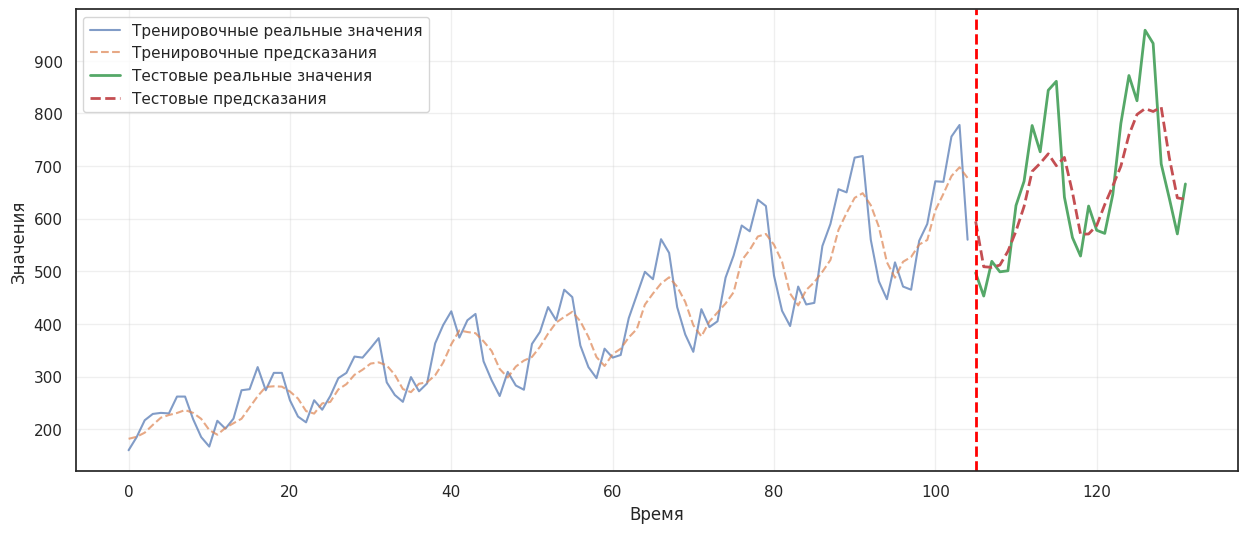

In [35]:
plt.figure(figsize=(15, 6))

train_len = len(X_train)
test_len = len(X_test)

y_train_pred = model_GRU.predict(X_train)

plt.plot(range(train_len), y_train[:train_len], label='Тренировочные реальные значения', linewidth=1.5, alpha=0.7)
plt.plot(range(train_len), y_train_pred, label='Тренировочные предсказания', linewidth=1.5, alpha=0.7, linestyle='--')
plt.plot(range(train_len, train_len + test_len), y_test, label='Тестовые реальные значения', linewidth=2)
plt.plot(range(train_len, train_len + test_len), y_pred, label='Тестовые предсказания', linewidth=2, linestyle='--')

plt.axvline(x=train_len, color='red', linestyle='--', linewidth=2)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Значения', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
from keras.layers import Dense, LSTM

lstm_layer = LSTM(50, return_sequences=False)

inputs = keras.Input(shape=(12, 1))
x = lstm_layer(inputs)
outputs = Dense(1)(x)

model_LSTM = keras.Model(inputs=inputs, outputs=outputs)

model_LSTM.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_LSTM.fit(X_train, y_train, epochs=25)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 175298.7500 - mae: 393.0135
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 175235.1250 - mae: 392.9295
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 175170.2500 - mae: 392.8380
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 175051.5000 - mae: 392.6830
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 174914.8750 - mae: 392.5007
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 174722.0781 - mae: 392.2288
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 174329.2031 - mae: 391.7388
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 173992.0156 - mae: 391.3015
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 173598.7188 - mae: 390.8146
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 173310.7031 - mae: 390.4678
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 173159.5781 - mae: 390.2687
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 17295

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


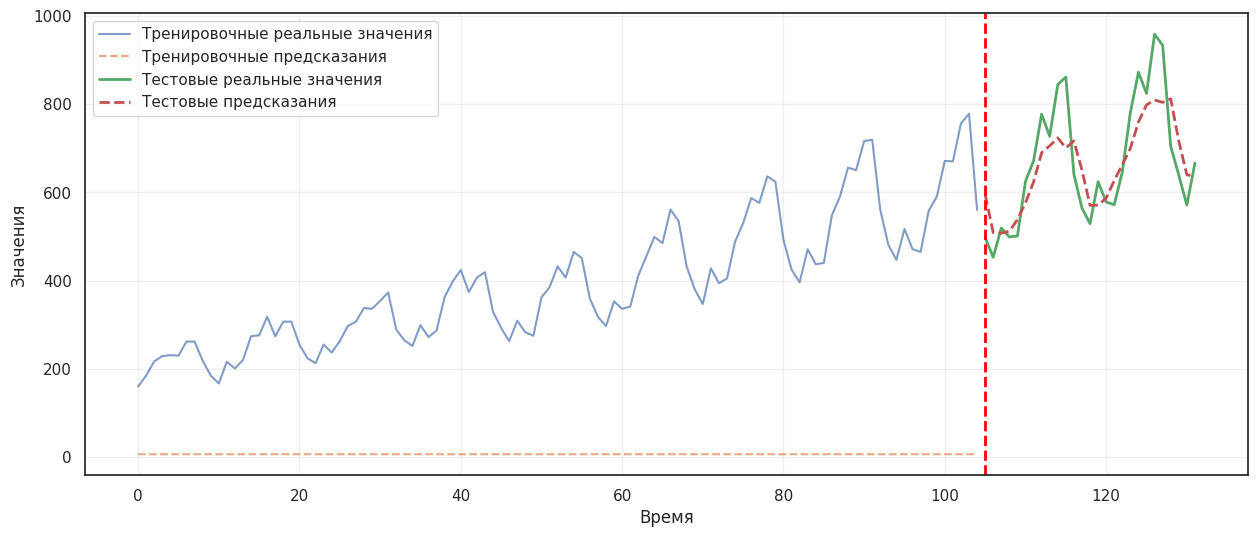

In [37]:
plt.figure(figsize=(15, 6))

train_len = len(X_train)
test_len = len(X_test)

y_train_pred = model_LSTM.predict(X_train)

plt.plot(range(train_len), y_train[:train_len], label='Тренировочные реальные значения', linewidth=1.5, alpha=0.7)
plt.plot(range(train_len), y_train_pred, label='Тренировочные предсказания', linewidth=1.5, alpha=0.7, linestyle='--')
plt.plot(range(train_len, train_len + test_len), y_test, label='Тестовые реальные значения', linewidth=2)
plt.plot(range(train_len, train_len + test_len), y_pred, label='Тестовые предсказания', linewidth=2, linestyle='--')

plt.axvline(x=train_len, color='red', linestyle='--', linewidth=2)
plt.xlabel('Время', fontsize=12)
plt.ylabel('Значения', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
import torch
import torch.nn as nn

sequence_length = 12
n_features = 1
hidden_size = 50
output_size = 1

class RNNModel(nn.Module):
    def __init__(self):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, hn = self.rnn(x)
        last_output = out[:, -1, :]
        out = self.fc(last_output)
        return out

model_RNN = RNNModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_RNN.parameters(), lr=0.001)

num_epochs = 30

for epoch in range(num_epochs):
    model_RNN.train()
    optimizer.zero_grad()

    X_batch = torch.randn(32, sequence_length, n_features) #batch_size, seq_len, n_features
    y_batch = torch.randn(32, 1)

    outputs = model_RNN(X_batch)
    loss = criterion(outputs, y_batch)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [2/30], Loss: 1.5503
Epoch [4/30], Loss: 1.3609
Epoch [6/30], Loss: 0.9318
Epoch [8/30], Loss: 1.1585
Epoch [10/30], Loss: 1.2159
Epoch [12/30], Loss: 1.1688
Epoch [14/30], Loss: 0.8033
Epoch [16/30], Loss: 1.3512
Epoch [18/30], Loss: 0.8521
Epoch [20/30], Loss: 0.6047
Epoch [22/30], Loss: 0.7316
Epoch [24/30], Loss: 0.6800
Epoch [26/30], Loss: 0.9438
Epoch [28/30], Loss: 0.7390
Epoch [30/30], Loss: 0.9639


In [51]:
class GRUModel(nn.Module):
    def __init__(self):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, hn = self.gru(x)
        last_output = out[:, -1, :]
        out = self.fc(last_output)
        return out

model = GRUModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    X_batch = torch.randn(32, sequence_length, n_features)
    y_batch = torch.randn(32, 1)

    outputs = model(X_batch)
    loss = criterion(outputs, y_batch)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 2 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [2/30], Loss: 0.9092
Epoch [4/30], Loss: 0.5083
Epoch [6/30], Loss: 0.8855
Epoch [8/30], Loss: 1.4825
Epoch [10/30], Loss: 0.9002
Epoch [12/30], Loss: 1.4877
Epoch [14/30], Loss: 1.0491
Epoch [16/30], Loss: 1.0942
Epoch [18/30], Loss: 1.3616
Epoch [20/30], Loss: 0.7250
Epoch [22/30], Loss: 0.9284
Epoch [24/30], Loss: 1.2124
Epoch [26/30], Loss: 0.7233
Epoch [28/30], Loss: 0.8102
Epoch [30/30], Loss: 1.3690


In [53]:
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_output = out[:, -1, :]
        out = self.fc(last_output)
        return out

model = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    X_batch = torch.randn(32, sequence_length, n_features)
    y_batch = torch.randn(32, 1)

    outputs = model(X_batch)
    loss = criterion(outputs, y_batch)

    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [5/50], Loss: 0.6673
Epoch [10/50], Loss: 0.6599
Epoch [15/50], Loss: 0.6591
Epoch [20/50], Loss: 1.0007
Epoch [25/50], Loss: 1.3243
Epoch [30/50], Loss: 0.8525
Epoch [35/50], Loss: 0.7848
Epoch [40/50], Loss: 1.3289
Epoch [45/50], Loss: 1.3610
Epoch [50/50], Loss: 1.1159
